# 1. Introducción
---

Este notebook trata sobre la creación de un modelo de regresión capaz de estimar el valor de DBWT basándose en un Dataset que proviene del Sistema Nacional de Estadísticas Vitales. 

Se utiliza un modelo de Gradient Boosting Decision Trees, CatBoost. Gestiona las variables categóricas sin necesidad de codificación manual y los valores nulos. Es eficaz a la hora de encontrar interacciones no lineales entre features. También hablando con mis compañeros, era el que mejor resultado nos estaba dando a todos comparado a otros modelos. 


# 2. Librerías 

---

In [ ]:
# Importaciones necesarias
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, Pool

# Scikit-learn para arquitectura Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


# graphics
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 20})
plt.rcParams["figure.figsize"] = (11, 6.8)

import seaborn as sns
sns.set(font_scale=1)

# Configuración Estándar (PEP 8 y Reproducibilidad)
pd.set_option('display.max_columns', None)
seed = 42
np.random.seed(seed)

import missingno as msno

# 3. Investigacion del dataset
---

In [ ]:
train = pd.read_csv("/kaggle/input/u-tad-birth-weight-point-prediction-2025/train.csv")


print(train.shape)
print(train.info())

(7000, 38)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 38 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           7000 non-null   int64  
 1   ATTEND       7000 non-null   int64  
 2   BFACIL       7000 non-null   int64  
 3   BMI          7000 non-null   float64
 4   CIG_0        7000 non-null   int64  
 5   DLMP_MM      7000 non-null   int64  
 6   DMAR         7000 non-null   object 
 7   DOB_MM       7000 non-null   int64  
 8   DOB_TT       6436 non-null   float64
 9   DOB_WK       7000 non-null   int64  
 10  FAGECOMB     7000 non-null   int64  
 11  FEDUC        7000 non-null   int64  
 12  ILLB_R       7000 non-null   int64  
 13  ILOP_R       7000 non-null   int64  
 14  ILP_R        7000 non-null   int64  
 15  LD_INDL      7000 non-null   object 
 16  MAGER        7000 non-null   int64  
 17  MBSTATE_REC  7000 non-null   int64  
 18  MEDUC        7000 non-null   int64  


## Valores nulos
Se delega la imputación y el tratamiento de los valores nulos a CatBoost.

Para features categóricas, CatBoost asigna automáticamente los valores nulos a una categoría implícita separada o los gestiona mediante el esquema de codificación de features propio del algoritmo.

Mis pruebas iniciales demostraron que la imputación manual de valores nulos resultó en un rendimiento inferior (mayor RMSE/menor accuracy) en comparación con el tratamiento nativo de datos faltantes de CatBoost.

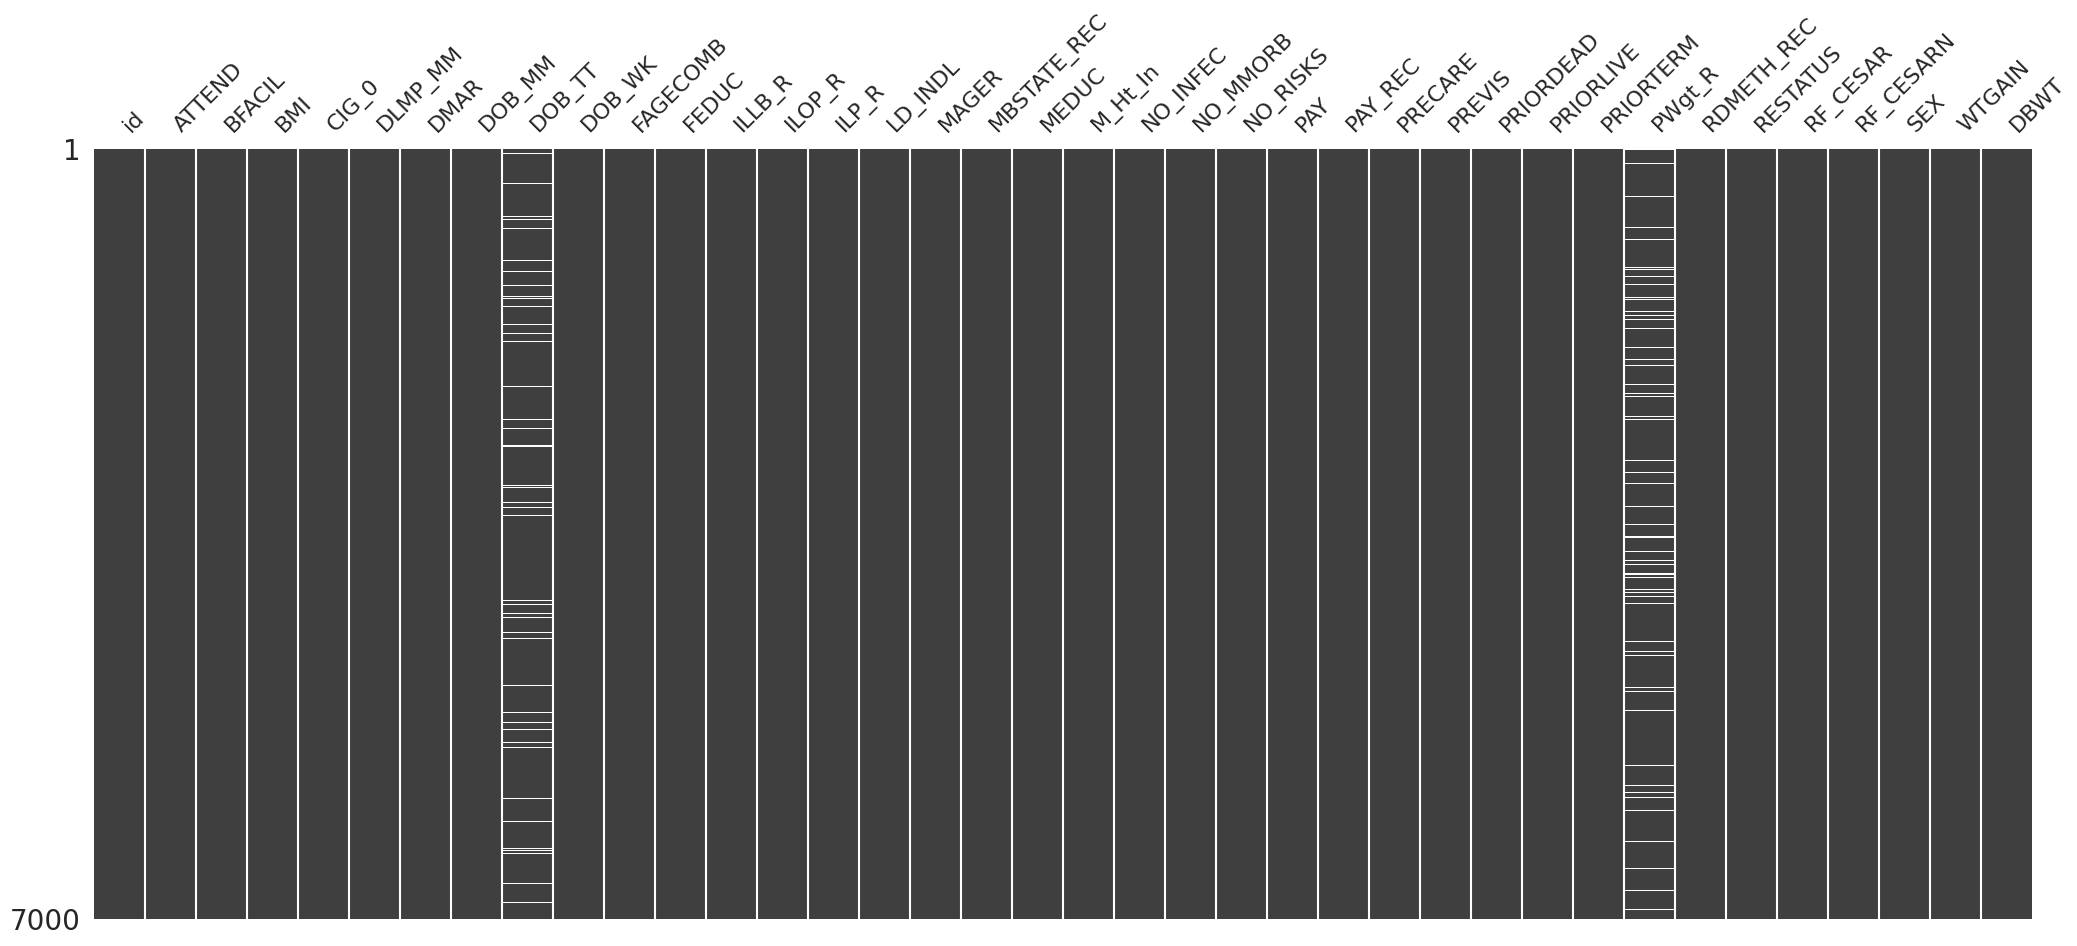

In [202]:
msno.matrix(train, sparkline=False);

## Analisis del target

Tratamiento de Outliers y Consistencia del Target: Se define el rango normal de peso al nacer (2500g a 4000g). Se implementará una estrategia de eliminación de outliers para registros con DBWT inferior a 1000g, asumiendo que representan datos anómalos o extremos que podrían sesgar el entrenamiento del modelo de regresión.

Las métricas de distribución confirman una baja asimetría (skewness: $-0.46$) y una curtosis (1.04) cercana a la normal (distribución mesocúrtica). 

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


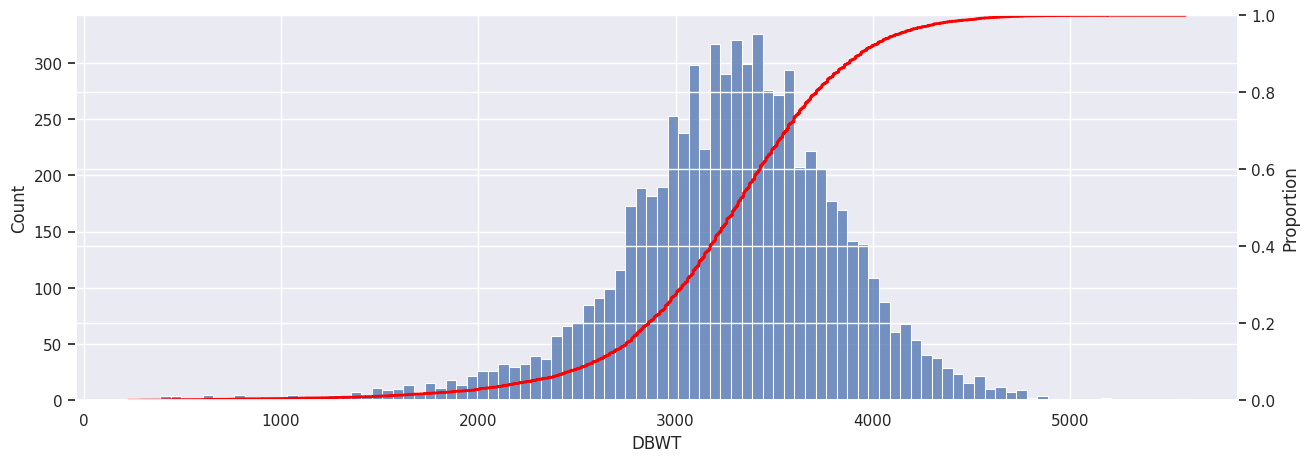

Curtosis =  1.0486372216271387
Skewness =  -0.46338616189443765


In [203]:
fig, (ax1) = plt.subplots(1, 1, figsize=(15, 5))  
ax2 = ax1.twinx()  
sns.histplot(data=train, x="DBWT", bins=100, ax=ax1)  
sns.ecdfplot(data=train, x="DBWT", color="red", lw=2, ax=ax2)  
plt.show()

train = train[(train['DBWT'] >= 1000)]

curtosis = train['DBWT'].kurt()
skewness = train['DBWT'].skew()

print("Curtosis = ", curtosis)
print("Skewness = ", skewness)

## Analisis de los features

Se establece una heurística programática para clasificar las features en tipos discretos (Categóricas) y continuos (Numéricas). Esta inferencia inicial combina dos criterios principales: el tipo de dato nativo del DataFrame (objeto/categoría) y un umbral de cardinalidad (max_unique_categorical = 20). Las features numéricas con cardinalidad inferior al umbral son promovidas a categóricas para ser tratadas como datos nominales por el pipeline CatBoost.

In [204]:
print(train.nunique())

def clasificar_features(df, max_unique_categorical=20):
    categoricas = []
    numericas = []
    
    for col in df.columns:
        uniques = df[col].nunique(dropna=True)
        
        # Si no es numérico → categórica
        if df[col].dtype == 'object' or df[col].dtype.name == 'category':
            categoricas.append(col)
        
        # Si es numérico pero con pocos valores únicos → categórica
        elif uniques <= max_unique_categorical:
            categoricas.append(col)
        
        # Si es numérico con muchos valores únicos → numérica
        else:
            numericas.append(col)
    
    return categoricas, numericas

categoricas, numericas = clasificar_features(train)

print("Categóricas:", categoricas)
print("\nNuméricas:", numericas)

id             6969
ATTEND            6
BFACIL            7
BMI             380
CIG_0            23
DLMP_MM          13
DMAR              3
DOB_MM           12
DOB_TT         1413
DOB_WK            7
FAGECOMB         48
FEDUC             9
ILLB_R          211
ILOP_R          187
ILP_R           199
LD_INDL           2
MAGER            36
MBSTATE_REC       3
MEDUC             9
M_Ht_In          29
NO_INFEC          3
NO_MMORB          3
NO_RISKS          2
PAY               8
PAY_REC           5
PRECARE          11
PREVIS           40
PRIORDEAD         8
PRIORLIVE        13
PRIORTERM        11
PWgt_R          249
RDMETH_REC        5
RESTATUS          4
RF_CESAR          2
RF_CESARN         6
SEX               2
WTGAIN           97
DBWT           1346
dtype: int64
Categóricas: ['ATTEND', 'BFACIL', 'DLMP_MM', 'DMAR', 'DOB_MM', 'DOB_WK', 'FEDUC', 'LD_INDL', 'MBSTATE_REC', 'MEDUC', 'NO_INFEC', 'NO_MMORB', 'NO_RISKS', 'PAY', 'PAY_REC', 'PRECARE', 'PRIORDEAD', 'PRIORLIVE', 'PRIORTERM', 'RDMET

### 1. Características Numéricas (Continuas y Discretas)

| Categoría | Variable | Descripción |
| :--- | :--- | :--- |
| **Físicas / Salud** | `BMI` | Índice de masa corporal. |
| **Físicas / Salud** | `WTGAIN` | Peso ganado durante el embarazo. |
| **Físicas / Salud** | `PWgt_R` | Peso materno pre-embarazo. |
| **Físicas / Salud** | `M_Ht_In` | Altura de la madre en pulgadas. |
| **Físicas / Salud** | `CIG_0` | Conteo de cigarrillos consumidos al inicio del embarazo. |
| **Físicas / Salud** | `MAGER` | Edad de la madre. |
| **Físicas / Salud** | `FAGECOMB` | Edad del padre. |
| **Historial / Conteos** | `PREVIS` | Número de visitas prenatales. |
| **Historial / Conteos** | `PRIORDEAD` | Conteo de fetos previos que resultaron en muerte. |
| **Historial / Conteos** | `PRIORLIVE` | Número de hijos previos vivos. |
| **Historial / Conteos** | `PRIORTERM` | Número de terminaciones previas. |
| **Historial / Conteos** | `RF_CESARN` | Número de cesáreas previas. |
| **Intervalos de Tiempo** | `ILLB_R` | Intervalo de tiempo (en meses) desde el último nacimiento vivo. |
| **Intervalos de Tiempo** | `ILOP_R` / `ILP_R` | Intervalo desde el último otro embarazo. |
| **Intervalos de Tiempo** | `PRECARE` | Mes en que inició el cuidado prenatal. |

---

### 2. Características Categóricas

#### A. Nominales

| Categoría | Variable |
| :--- | :--- |
| **Demográficas** | `DMAR` |
| **Demográficas** | `MBSTATE_REC` |
| **Demográficas** | `RESTATUS` |
| **Datos Parto** | `ATTEND` |
| **Datos Parto** | `BFACIL` |
| **Datos Parto** | `PAY` / `PAY_REC` |
| **Datos Parto** | `RDMETH_REC` |

#### B. Ordinales 

| Variable | Descripción |
| :--- | :--- |
| `MEDUC` | Nivel de educación de la madre. |
| `FEDUC` | Nivel de educación del padre. |

---

### 3. Caracteristicas Especiales 

#### A. Indicadores Binarios (Flags/Booleanos)

* `NO_INFEC`
* `NO_MMORB`
* `NO_RISKS`
* `LD_INDL`

#### B. Variables de Fecha/Tiempo (Cíclicas) 

Estas features requieren una transformación Seno/Coseno para preservar la continuidad temporal y evitar la discontinuidad artificial (discretización del tiempo).

| Variable | Tipo | Transformaciones a realizar |
| :--- | :--- | :--- |
| `DOB_WK` | Día de la semana (1-7) ||
| `DOB_MM` | Mes de nacimiento | **Transformación Cíclica** (Seno/Coseno)|
| `DLMP_MM` | Mes de Último Periodo Menstrual | **Transformación Cíclica** (Seno/Coseno)|
| `DOB_TT` | Hora del nacimiento | **Transformación Cíclica** (Seno/Coseno)|

#### C. Identificadores Únicos (Exclusión del Modelado)

* `id`


## Correlacion

In [205]:
columnas_numericas_matriz = ["BMI", "WTGAIN", "PWgt_R", "M_Ht_In", "CIG_0", "MAGER", "FAGECOMB", "PREVIS", "PRIORDEAD", "PRIORLIVE"
                      , "PRIORTERM", "RF_CESARN", "ILLB_R", "ILOP_R", "ILP_R", "PRECARE"]

train_numericas = train[columnas_numericas_matriz]
train_numericas.corr(method='pearson', numeric_only=True).style.background_gradient(cmap='coolwarm', axis=None).format(precision=2)

,BMI,WTGAIN,PWgt_R,M_Ht_In,CIG_0,MAGER,FAGECOMB,PREVIS,PRIORDEAD,PRIORLIVE,PRIORTERM,RF_CESARN,ILLB_R,ILOP_R,ILP_R,PRECARE
BMI,1.00,0.26,0.91,0.26,0.06,0.04,0.08,0.14,0.05,0.07,0.04,0.09,-0.03,0.00,-0.01,0.15
WTGAIN,0.26,1.00,0.39,0.14,0.05,-0.01,0.02,0.11,0.05,0.05,0.04,-0.01,0.08,0.02,0.08,0.11
PWgt_R,0.91,0.39,1.00,0.22,0.07,0.04,0.08,0.15,0.06,0.08,0.05,0.05,-0.01,0.01,0.01,0.17
M_Ht_In,0.26,0.14,0.22,1.00,0.07,0.06,0.00,0.06,0.07,0.06,0.05,-0.05,0.03,-0.02,0.02,0.04
CIG_0,0.06,0.05,0.07,0.07,1.00,-0.05,0.10,0.03,0.07,0.08,0.06,0.01,-0.00,-0.02,0.01,0.05
MAGER,0.04,-0.01,0.04,0.06,-0.05,1.00,0.03,0.03,0.01,0.10,0.03,0.16,-0.23,-0.10,-0.17,0.01
FAGECOMB,0.08,0.02,0.08,0.00,0.10,0.03,1.00,-0.01,0.04,0.06,0.03,0.06,-0.03,0.00,0.00,0.06
PREVIS,0.14,0.11,0.15,0.06,0.03,0.03,-0.01,1.00,0.16,0.15,0.16,-0.02,0.05,0.02,0.06,0.65
PRIORDEAD,0.05,0.05,0.06,0.07,0.07,0.01,0.04,0.16,1.00,0.93,0.74,-0.02,0.06,0.03,0.06,0.16
PRIORLIVE,0.07,0.05,0.08,0.06,0.08,0.10,0.06,0.15,0.93,1.00,0.70,0.06,-0.12,-0.01,-0.07,0.17


Podemos ver que algunas columans tienen mucha correlacion con otras:
- PRIORDEAD y PRIORLIVE muestran una fuerte colinealidad positiva $(\rho = 0.93)$, lo que sugiere que ambas features capturan información redundante sobre el historial reproductivo materno.
- La alta correlación entre el peso materno pre-embarazo (PWgt_R) y el Índice de Masa Corporal (BMI) $(\rho = 0.91)$ es esperada, ya que BMI es un cálculo derivado parcialmente de PWgt_R (y la altura M_Ht_In).
- Se observa una correlación significativa $(\rho = 0.75)$ entre el intervalo desde el último nacimiento vivo (ILLB_R) y el intervalo desde el último otro embarazo (ILOP_R).

# 4. Modularización: Clases Custom Transformer
---

In [ ]:
class CyclicFeatureEncoder(BaseEstimator, TransformerMixin):
    """
    Transformador para codificar características cíclicas (tiempo, mes, día) usando sen/cos.
    """
    def __init__(self, col_name, max_val, is_time=False):
        self.col_name = col_name
        self.max_val = max_val
        self.is_time = is_time

    def convertir_hora_a_minutos(self, hhmm):
        if pd.isna(hhmm):
            return np.nan
        try:
            hhmm_str = f"{int(hhmm):04d}" 
            horas = int(hhmm_str[:2])
            minutos = int(hhmm_str[2:])
            return horas * 60 + minutos
        except (ValueError, TypeError):
            return np.nan

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_copy = X.copy()
        
        # Paso 1: Pre-procesamiento de Hora (si aplica)
        if self.is_time:
            temp_col = 'temp_minutes_' + self.col_name
            # Vectorización para eficiencia
            X_copy[temp_col] = X_copy[self.col_name].apply(self.convertir_hora_a_minutos)
            col_to_encode = temp_col
        else:
            col_to_encode = self.col_name
        
        # Paso 2: Codificación Cíclica (Sen/Cos)
        if col_to_encode in X_copy.columns:
            # Fórmula para preservar la relación de vecindad: sin(2*pi*x/max)
            X_copy[f'{self.col_name}_sin'] = np.sin(2 * np.pi * X_copy[col_to_encode] / self.max_val)
            X_copy[f'{self.col_name}_cos'] = np.cos(2 * np.pi * X_copy[col_to_encode] / self.max_val)
            
            # Paso 3: Limpieza (Eliminar columnas originales e intermedias)
            X_copy.drop(columns=[self.col_name], inplace=True, errors='ignore')
            if self.is_time:
                X_copy.drop(columns=[temp_col], inplace=True, errors='ignore')

        return X_copy

# 5. Carga de datos
---

In [207]:
def load_and_clean_data(train_path, test_path):
    """Carga los datos"""
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)
    
    return train_df, test_df

## Definicion de constantes y rutas

In [208]:
TARGET_COL = 'DBWT'
ID_COL = 'id'
TRAIN_PATH = "/kaggle/input/u-tad-birth-weight-point-prediction-2025/train.csv"
TEST_PATH = "/kaggle/input/u-tad-birth-weight-point-prediction-2025/test.csv"

## Clasificacion de columnas

In [209]:
columnas_jerarquicas = ["MEDUC", "FEDUC", "RESTATUS"] # Ordinales
columnas_categoricas = ["LD_INDL", "ATTEND", "BFACIL", "PAY", "PAY_REC", "NO_INFEC", "NO_MMORB", "NO_RISKS", "DMAR", "MBSTATE_REC", "RF_CESAR", "SEX"]
columnas_numericas = ["BMI", "WTGAIN", "M_Ht_In", "CIG_0", "MAGER", "FAGECOMB", "PREVIS", "PRIORLIVE", "PRIORTERM", "RF_CESARN", "ILOP_R", "ILP_R", "PRECARE"]
columnas_ciclicas = {
    'DOB_TT': 1440, # Hora (minutos)
    'DOB_MM': 12,    # Mes
    'DLMP_MM': 12,   # Mes del último periodo menstrual
    'DOB_WK': 7      # Día de la semana
}
columnas_a_eliminar = [
    'PRIORDEAD',  # Correlación alta con PRIORLIVE (0.93)
    'PWgt_R',     # Correlación alta con BMI (0.88)
    'ILLB_R'      # Correlación alta con ILOP_R (0.75) y ILP_R
]

# 6. Función Principal de Entrenamiento y Predicción

Esta función encapsula el flujo de trabajo completo del modelo, desde la ingesta de datos limpios hasta la generación del archivo final de predicciones.

#### Fases del Pipeline:
1.  **División Estratégica:** Separación del conjunto de entrenamiento en subconjuntos de Entrenamiento y Validación (80/20) para monitorear el rendimiento y prevenir el *overfitting* mediante *Early Stopping*.
2.  **Ingeniería de Características Cíclicas (FE):** Aplicación de la transformación Seno/Coseno a las *features* temporales para preservar la continuidad. 
3.  **Preparación de Datos Nativos:** Creación de los objetos `Pool` de CatBoost, donde las *features* categóricas se pasan explícitamente para aprovechar los esquemas de codificación internos del algoritmo.
4.  **Entrenamiento y Regularización:** Inicialización del `CatBoostRegressor` con hiperparámetros optimizados y entrenamiento sobre el `train_pool`. Se utiliza el `val_pool` como *eval_set* para aplicar la técnica de **Early Stopping**.
5.  **Evaluación Final:** Cálculo del RMSE en el conjunto de Validación para medir el rendimiento general y generación del archivo de *submission*.

In [210]:
def create_encoders():
    """Crea y devuelve las instancias del codificador cíclico."""
    return [
        CyclicFeatureEncoder('DOB_TT', 1440, is_time=True),
        CyclicFeatureEncoder('DOB_MM', 12),
        CyclicFeatureEncoder('DLMP_MM', 12),
        CyclicFeatureEncoder('DOB_WK', 7)
    ]

def train_and_predict():
    """Ejecuta el flujo de trabajo completo para CatBoost."""
    
    # 1 Carga y Limpieza Inicial
    train_df, test_df = load_and_clean_data(TRAIN_PATH, TEST_PATH)
    
    # 2 División de Datos
    X = train_df.drop(columns=[TARGET_COL, ID_COL])
    y = train_df[TARGET_COL]
    
    # División Train/Validation (80/20)
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=seed)
    X_test = test_df.drop(columns=[ID_COL])
    print(f"Datos divididos. Train: {X_train.shape}, Validation: {X_val.shape}")

    # 3 Feature Engineering
    print("\nAplicando Feature Engineering Cíclico...")
    encoders = create_encoders()
    for encoder in encoders:
        X_train = encoder.transform(X_train)
        X_val = encoder.transform(X_val)
        X_test = encoder.transform(X_test)

    print("\nDropeando columnas...")
    X_train = X_train.drop(columns=columnas_a_eliminar, errors='ignore')
    X_val = X_val.drop(columns=columnas_a_eliminar, errors='ignore')
    X_test = X_test.drop(columns=columnas_a_eliminar, errors='ignore')

    # Definición de todas las características categóricas
    cat_features = columnas_categoricas + columnas_jerarquicas 
    
    # 4.1 Creación de Pool (Formato nativo de CatBoost)
    train_pool = Pool(
        data=X_train, 
        label=y_train, 
        cat_features=cat_features
    )
    val_pool = Pool(
        data=X_val, 
        label=y_val, 
        cat_features=cat_features
    )

    # 4.2 Inicialización del Modelo con Hiperparámetros
    cat_model = CatBoostRegressor(
        iterations = 3000, 
        learning_rate = 0.03,      
        depth = 8,                 
        l2_leaf_reg = 5,           
        border_count = 128,        
        
        cat_features = cat_features, 
        loss_function ='RMSE',
        random_state = seed, 
        verbose = 0,
        
        thread_count=-1
    )
    
    print("\nIniciando entrenamiento del CatBoostRegressor con Early Stopping...")
    cat_model.fit(
        train_pool, 
        eval_set=val_pool, 
        early_stopping_rounds=75
    )
    print(f"Entrenamiento completado en {cat_model.get_best_iteration()} iteraciones.")

    # 4.5 Evaluación y Predicción
    
    # Evaluación en X_val
    y_pred_val = cat_model.predict(X_val)
    rmse = mean_squared_error(y_val, y_pred_val, squared=False)

    print("\n--- Evaluación en Conjunto de Validación ---")
    print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.2f}")
    
    # Predicción en el Conjunto de Prueba
    print("\nGenerando predicciones en el conjunto de prueba...")
    y_pred = cat_model.predict(X_test)    
    # 4.6 Creación del Archivo de Entrega
    submission = pd.read_csv("/kaggle/input/u-tad-birth-weight-point-prediction-2025/sample_submission.csv")
    submission["DBWT"] = y_pred.round().astype(int)
    submission.to_csv('submission.csv',index=False)

    print("\nPredicciones generadas. Muestra de la entrega:")
    print(submission.head())

In [211]:
model = train_and_predict()

Datos divididos. Train: (5600, 36), Validation: (1400, 36)

Aplicando Feature Engineering Cíclico...

Dropeando columnas...

Iniciando entrenamiento del CatBoostRegressor con Early Stopping...


/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sin
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in cos
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sin
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in cos
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sin
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in cos
  result = getattr(uf

Entrenamiento completado en 1221 iteraciones.

--- Evaluación en Conjunto de Validación ---
RMSE (Raíz del Error Cuadrático Medio): 479.90

Generando predicciones en el conjunto de prueba...

Predicciones generadas. Muestra de la entrega:
     id  DBWT
0  7000  3689
1  7001  3110
2  7002  3561
3  7003  3229
4  7004  3291


# 7. Resultados
---

### 6.1 Resultados del Modelo Baseline

Al principio cuando no conocía mucho CatBoost, Trate los nulos, escale las funciones numéricas y realicé los encoding de las variables categóricas. Me sorprende hoy en día el resultado de está implemetación en el Private Test. 

| Metrica | Validation Set | Public Test Set | Private Test Set |
| :--- | :--- | :--- |:--- |
| **RMSE** | 455.98 | 549.55 | 517.47

Al preprocesar manualmente los datos, podemos observar que el modelo estaba overfitted al conjunto de train/validation.

Hiperparametros:
{
    random_state=42, 
    loss_function='RMSE', 
    verbose=0,   
    iterations=1000  
}

### 6.2 Resultados de Modelo Optimizado

Optimice el modelo. Deje que catboost se encargase de la codificación de categorías y el tratamiento de nulos. Mejoré la ingeniería de features eliminando outliers del target y transformando las variables cíclicas (ej., mes de nacimiento) con funciones trigonométricas ($\sin$ y $\cos$).

| Metrica | Validation Set | Public Test Set | Private Test Set |
| :--- | :--- | :--- |:--- |
| **RMSE** | 450.98| 511.83 | 498.50 |

Mejoraron las métricas en todos los sets. Aquí me di cuenta de las capacidades de CatBoost.

Hiperparametros:
{
    random_state=42, 
    loss_function='RMSE', 
    verbose=0,   
    iterations=1000  
}

### 6.3 Resultados de Modelo Optimizado con tuning de hiperparámetros

Implementé una mejor detección de variables categóricas, análisis de correlaciones y el uso de CatBoost Pools, junto con la estrategia de regularización suave (learning_rate=0.03, l2_leaf_reg=5),.

| Metrica | Validation Set | Public Test Set | Private Test Set |
| :--- | :--- | :--- |:--- |
| **RMSE** | 479.90 | 505.01| 492.34 |

Se puede observar que se redució el overfitting y mejoraron las métricas.  

Hiperparametros:
{
    iterations = 3000, 
    learning_rate = 0.03,      
    depth = 8,                 
    l2_leaf_reg = 5,           
    border_count = 128,        
    cat_features = cat_features, 
    loss_function ='RMSE',
    random_state = seed, 
    verbose = 0,
    thread_count=-1
}

# 8. Conclusión
---

- Aprendí a utilizar CatBoost y descubrí su potencial
- La implemetación de las transformaciones sobre las variables temporales mejoraron bastante el rendimiento
- Pasos a seguir:
    - Nuevas columnas: Explorar el rendimiento con nuevos features que afecten el bajo peso al nacer. Algunas ideas: Combinación del IMC (BMI) y la ganancia de peso (WTGAIN). Relación de la edad de la madre (MAGER) y el historial de partos (PRIORTERM)
    - Buscar mejores tunings mediante optimización Bayesiana o probando más estrategias.
    - Encontrar patrones en los fallos del modelo.

# 9. Referencias
---
Para la realización de este notebook he consultado los materiales aportados por el profesor, he preguntado a compañeros de clase sobre sus experiencias con este modelo y otros y he revisado tutoriales en internet: 
- https://www.kaggle.com/code/mitribunskiy/tutorial-catboost-overview
